In [37]:
import pandas as pd

In [38]:
df = pd.read_csv("D:\DATA SCIENCE\Projects\Capstone_Project\Datasets\cleaned_amazon_audio.csv")

### Dataset Overview (Statistical Summary)

In [3]:
df.head()

,asin,product_title,brand,price,discount_percent,rating,review_count,category,product_link,search_term,value_score,device_type,is_wired,has_mic
0,B0C3V5X3QT,jbl tune 520bt wireless on ear headphones with...,jbl,2799.0,44.0,4.0,21600.0,audio,https://www.amazon.in/dp/B0C3V5X3QT,headphones,0.001429,headphones,0,1
1,B0FG2QT7H2,boat rockerz 512 anc40db hybrid anc 80h batter...,boat,2899.0,64.0,4.2,30600.0,audio,https://www.amazon.in/dp/B0FG2QT7H2,headphones,0.001449,headphones,0,1
2,B0DGTSRX3R,boat rockerz 480 rgb leds6 light modes 40mm dr...,boat,1499.0,60.0,4.1,4400.0,audio,https://www.amazon.in/dp/B0DGTSRX3R,headphones,0.002735,headphones,0,1
3,B0FQJGBKCX,ptron studio w 60hrs playtime wireless overear...,ptron,599.0,77.0,4.0,256.0,audio,https://www.amazon.in/dp/B0FQJGBKCX,headphones,0.006678,headphones,1,1
4,B0GCDPD6MB,snaphead vibe bluetooth wireless over ear head...,snaphead,999.0,88.0,4.0,0.0,audio,https://www.amazon.in/dp/B0GCDPD6MB,headphones,0.004004,headphones,0,0


In [5]:
df.columns

Index(['asin', 'product_title', 'brand', 'price', 'discount_percent', 'rating',
       'review_count', 'category', 'product_link', 'search_term',
       'value_score', 'device_type', 'is_wired', 'has_mic'],
      dtype='object')

In [5]:
df.shape

(1448, 14)

In [7]:
df.isnull().sum()


asin                0
product_title       0
brand               0
price               0
discount_percent    0
rating              0
review_count        0
category            0
product_link        0
search_term         0
value_score         0
device_type         0
is_wired            0
has_mic             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.nunique()

asin                1448
product_title       1428
brand                308
price                523
discount_percent      93
rating                37
review_count         569
category               1
product_link        1448
search_term            6
value_score          989
device_type            6
is_wired               2
has_mic                2
dtype: int64

### Visualizations

In [32]:
num_cols = ['price', 'discount_percent', 'rating', 'review_count', 'value_score']
cat_cols = [ 'device_type', 'is_wired', 'has_mic']

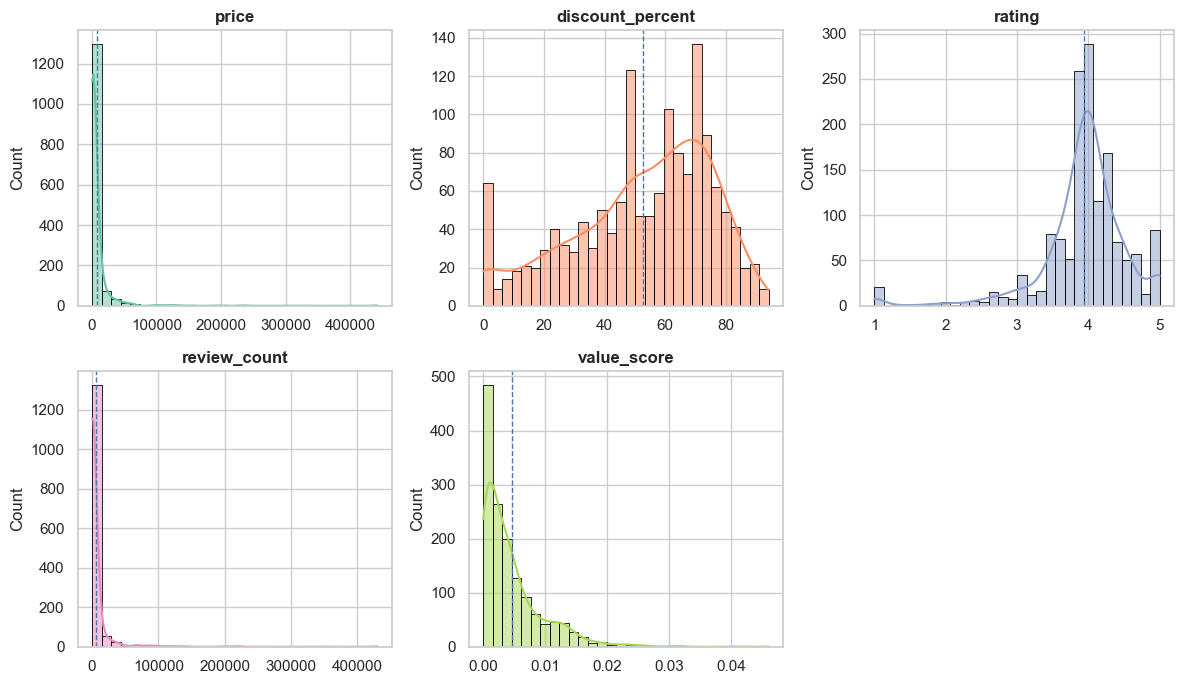

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font_scale=1.0)

num_cols = ['price', 'discount_percent', 'rating', 'review_count', 'value_score']
palette = sns.color_palette("Set2", len(num_cols))

# Create grid and  adjust rows or cols automatically
rows = 2
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(12,7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    
    ax = axes[i]
    
    sns.histplot(
        df[col],
        kde=True,
        bins=30,
        color=palette[i],
        edgecolor='black',
        ax=ax
    )
    
    # Mean line 
    ax.axvline(df[col].mean(), linestyle='--', linewidth=1)
    
    ax.set_title(col, fontsize=12, weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')

#  Remove extra empty plots
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

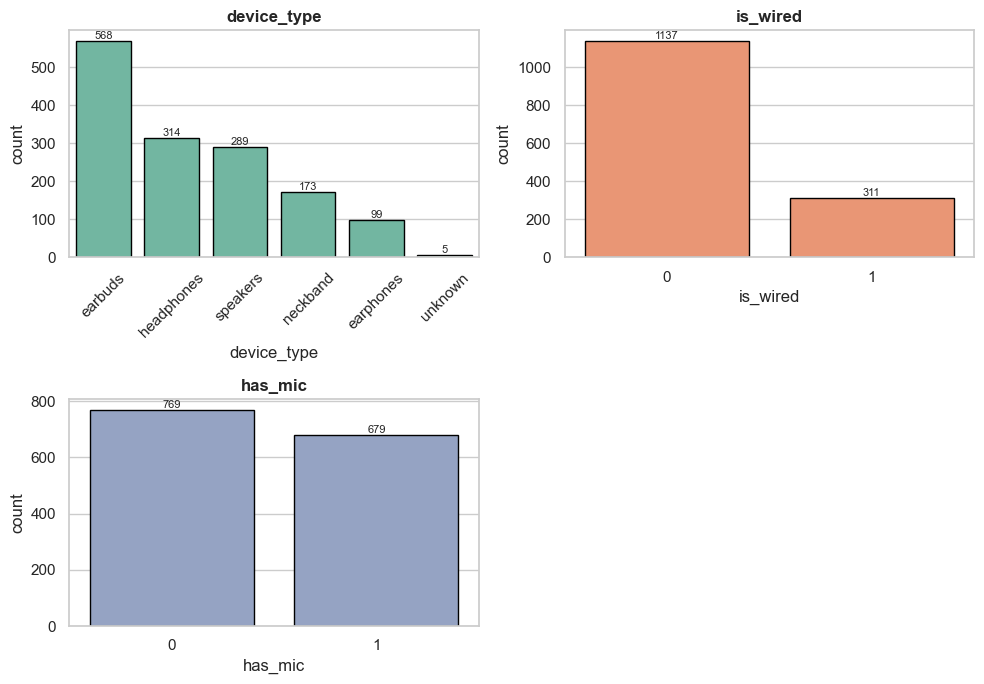

In [40]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,7))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    
    order = df[col].value_counts().index
    
    ax = sns.countplot(
        data=df,
        x=col,
        order=order,
        color=palette[i],
        edgecolor='black',
        ax=axes[i]
    )
    
    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_height())}',
            (p.get_x() + p.get_width()/2., p.get_height()),
            ha='center', va='bottom', fontsize=8
        )
    
    ax.set_title(col, fontsize=12, weight='bold')
    
    if df[col].nunique() > 3:
        ax.tick_params(axis='x', rotation=45)

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Relationships

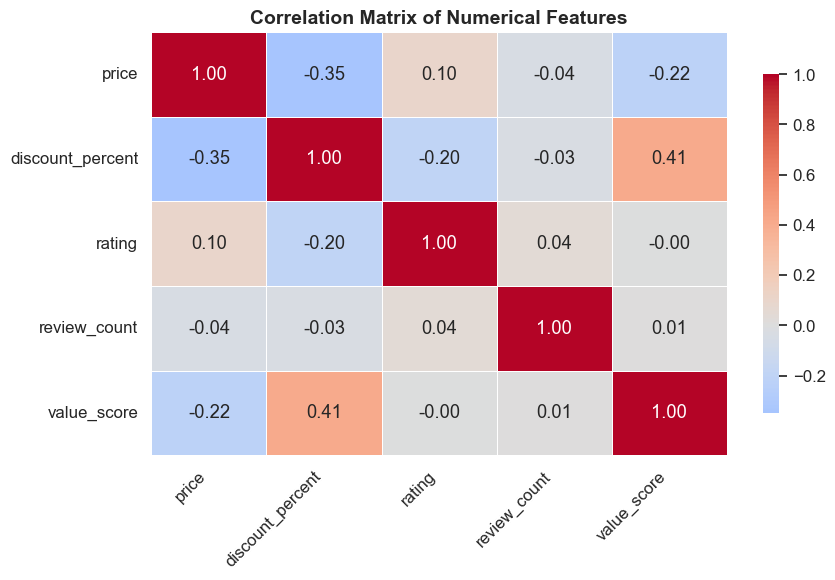

In [51]:
sns.set_theme(style="white", font_scale=1.1)

plt.figure(figsize=(9,6))

corr = df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",                 # 2 decimal places
    cmap="coolwarm",
    center=0,                  # better color balance
    linewidths=0.5,            # grid lines
    linecolor='white',
    cbar_kws={"shrink": 0.8}   # smaller color bar
)

plt.title('Correlation Matrix of Numerical Features', fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Categorical vs Numerical

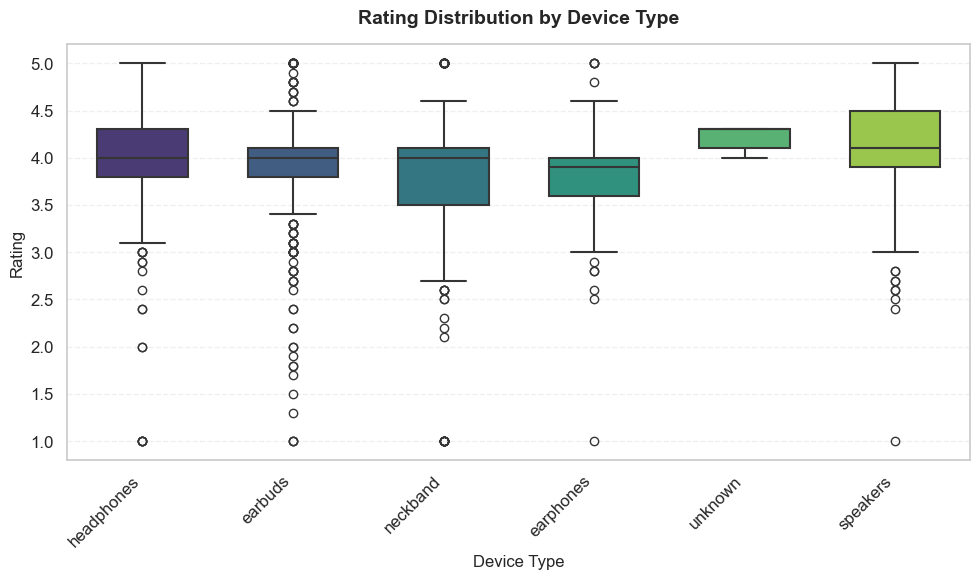

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set_theme(style="whitegrid", font_scale=1.1)

# Create figure
plt.figure(figsize=(10, 6))

# Create boxplot
sns.boxplot(
    x='device_type', 
    y='rating', 
hue='device_type',
    data=df,
    palette='viridis',
    linewidth=1.5,
    width=0.6
)

# Customize
plt.title('Rating Distribution by Device Type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Device Type', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

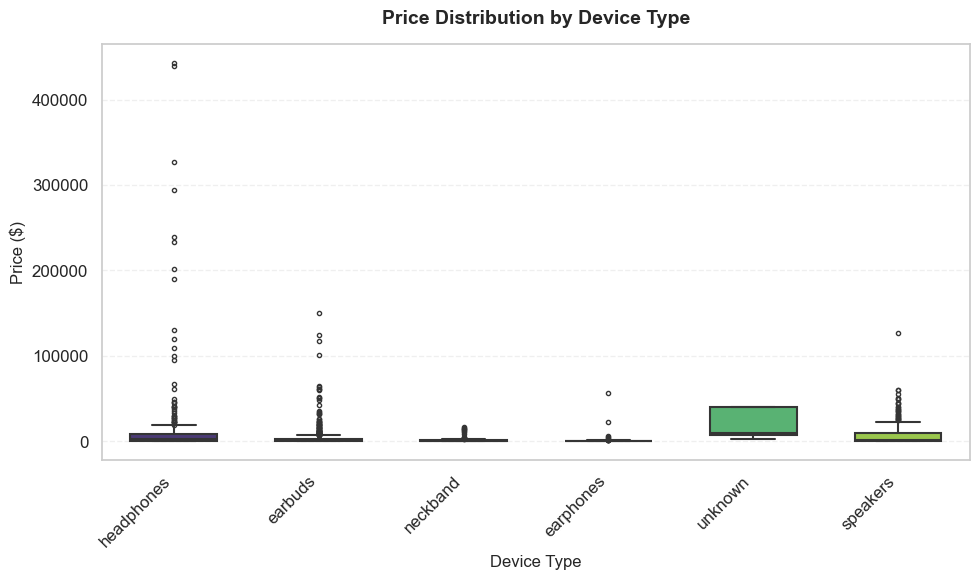

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set_theme(style="whitegrid", font_scale=1.1)

# Create figure
plt.figure(figsize=(10, 6))

# Create boxplot
ax = sns.boxplot(
    x='device_type', 
    y='price', 
    data=df,
    palette='viridis',
    hue='device_type',
    linewidth=1.5,
    fliersize=3,
    width=0.6
)

# Add title and labels
plt.title('Price Distribution by Device Type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Device Type', fontsize=12, fontweight='medium')
plt.ylabel('Price ($)', fontsize=12, fontweight='medium')

# Add grid
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Rotate x labels if needed
plt.xticks(rotation=45, ha='right')

# Adjust layout
plt.tight_layout()
plt.show()

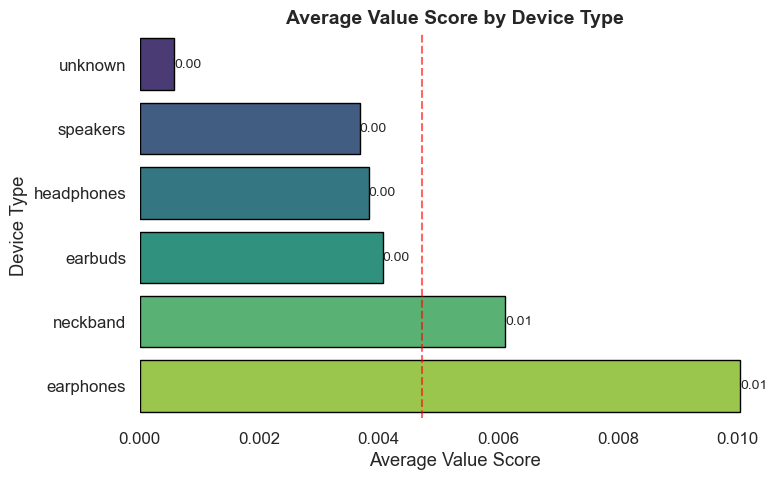

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white", font_scale=1.1)

# Prepare data
data = df.groupby('device_type')['value_score'].mean().sort_values().reset_index()

# Create gradient palette
palette = sns.color_palette("viridis", len(data))

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=data,
    x='value_score',
    y='device_type',
    hue='device_type',
    palette=palette,   
    legend=False,
    edgecolor='black'
)

# Add value labels
for i, v in enumerate(data['value_score']):
    ax.text(v, i, f"{v:.2f}", va='center', ha='left', fontsize=10)

# Optional: mean line (like your image)
mean_val = data['value_score'].mean()
plt.axvline(mean_val, color='red', linestyle='--', alpha=0.6)

sns.despine(left=True, bottom=True)

plt.title('Average Value Score by Device Type', fontsize=14, weight='bold')
plt.xlabel('Average Value Score')
plt.ylabel('Device Type')

plt.tight_layout()
plt.show()